# Multi-Task v4 + Corner-Chaining Loss (Q-18)

Single-variable ablation on top of [[MultiTaskEncoderUNetV4]]. Adds an **anatomical-chain soft loss** between adjacent vertebra keypoint predictions, encoded directly via the existing v4 kpt head. Per [[Open_Questions]] Q-18 — promoted to **first on the critical path** after [[2026-05-03_v4_tierA]] empirically rejected the Tier-A preprocessing bundle.

**What changes vs v4 (loss only):**
- New `chain_loss` raw term: differentiable soft-argmax over the kpt heatmap → predicted corner coords → L2 distance between adjacent-vertebra corner pairs:
  - `‖kpt_BL(n) − kpt_TL(n+1)‖` for n=0..15 (left-side chain)
  - `‖kpt_BR(n) − kpt_TR(n+1)‖` for n=0..15 (right-side chain)
  - 32 pair-distances per sample, normalized to image-relative scale (`/HM_H`), NaN-masked using `kpt_valid`
- `MixedLossWithChain` = clamped Kendall on `(seg, cobb)` + fixed `λ_kpt = 1.0` MSE + **fixed `λ_chain = 1.0`** chain loss
- Chain loss is **added throughout training** (no warmup ramp — v4's existing encoder-freeze warmup gives natural curriculum)

**What stays identical to v4:**
- Architecture (`MultiTaskEncoderUNet`, ResNet-34 encoder, in_ch=1, kpt head outputs `(B, 68, 128, 64)`)
- Dataset + preprocessing (bare `/255`, NOT Tier-A — Tier-A regressed both metrics, see [[2026-05-03_v4_tierA]])
- Augmentation (`augment_v5_cobb_aware`)
- Schedule (150 ep, patience 25, encoder freeze warmup 10 ep, dual-checkpoint)
- Single 80/20 split, same SEED → directly comparable to v4 leaderboard row

**Why a soft-argmax** (not argmax): argmax is non-differentiable; chain loss must propagate through the kpt head into the encoder. Soft-argmax = `Σ softmax(hm·T) · grid_coord`. Temperature `T=20` tuned on GT-Gaussian heatmaps (n=16 cases sweep): median sub-pixel accuracy (0.18 full-res px), mean 0.20 px. Lower T (≤10) → smear (12 px error from softmax tails). Higher T (≥50) → softmax saturation, falls back to discrete-bin quantization (0.85 px median). T=20 is the sweet spot for our heatmap magnitude (peak ≈ 1.0). Stays differentiable.

**Acceptance gate (vs v4 baseline):**
- best dice ≥ 0.680 (no regression — chain loss must not hurt seg through gradient sharing)
- best cobb_direct MAE ≤ 5.79° → chain prior was the floor-mover; promote to Q-10 stack
- 5.79° < cobb < 6.69° → modest help → still proceed to Q-10 / Q-01
- cobb ≥ 6.69° → chain prior alone is not enough → ablate `λ_chain` (try 0.1 / 5.0) or soft-argmax temperature `T` (try 5 / 30) before pivoting to Q-10

**Decision tree post-run** is filed in [[hot.md]] §Active Threads.

Cache key: `ai/models/checkpoints/multitask_v4_chain/<timestamp>_<hash>/` — isolated from v4 and from `multitask_v4_tierA` via the `chain_loss / lambda_chain / soft_argmax_temperature` fields in `run_config()`.


## 0 · Setup

In [1]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import (
    affine_transform,
    clahe_like,
    coarse_dropout,
    elastic_deform,
    gamma_correction,
    gaussian_blur,
    gaussian_noise,
    horizontal_flip,
    intensity_jitter,
)
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")


size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [4]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · I/O Contract — Three Targets per Sample

| Tensor | Shape | Dtype | Source | Notes |
|---|---|---|---|---|
| `image` | `(1, 512, 256)` | float32 | grayscale X-ray, normalized to `[0, 1]` | |
| `seg` | `(512, 256)` | int64 | per-pixel class `0..17` | |
| `kpt_heatmap` | `(68, 128, 64)` | float32 | Gaussian blob per corner at H/4 × W/4 | zeros where vertebra missing |
| `kpt_valid` | `(68,)` | bool | mask of finite keypoints | warn cases (14–16 vert) have ≤16 valid groups |
| `cobb` | `()` | float32 | scalar Cobb angle (degrees) | NaN when missing |
| `cobb_valid` | `()` | bool | True if `cobb` is finite | only ~178 / 249 cases |

Heatmaps live at H/4 × W/4 (= 128 × 64) to keep the keypoint output tensor under 10 MB per sample. Argmax + ×4 scaling recovers pixel coordinates.

In [5]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0  # gaussian sigma in heatmap-resolution pixels

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H,
    w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (heatmaps (K,h,w) float32, valid (K,) bool)."""
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx = x_full / downsample
        cy = y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid


def keypoints_from_heatmaps(
    hm: torch.Tensor,
    threshold: float = 0.1,
    upsample: int = HEATMAP_DOWNSAMPLE,
) -> tuple[np.ndarray, np.ndarray]:
    """Argmax peak per channel, scale to full-resolution pixel coords.

    Args:
        hm: (K, h, w) heatmap tensor
    Returns:
        coords: (K, 2) float array of (x, y) in full-resolution pixels (NaN if peak < threshold)
        scores: (K,) peak intensities
    """
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

In [6]:
sample = TRAINABLE.iloc[0]
case = preprocess_case(sample)
kps_full = case["kps"].numpy()
hm, valid = render_heatmaps(kps_full)
cobb = sample.get("cobb_angle_deg")
print(f"image          {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg            {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())[:6]}...")
print(f"kps (full px)  {kps_full.shape} finite={int(np.isfinite(kps_full).all(axis=1).sum())}/{TOTAL_KEYPOINTS}")
print(f"heatmaps       {hm.shape}  valid={int(valid.sum())}/{TOTAL_KEYPOINTS}  peak={hm.max():.3f}")
print(f"cobb           {cobb}")

image          (1, 512, 256) torch.float32
seg            (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5]...
kps (full px)  (68, 2) finite=68/68
heatmaps       (68, 128, 64)  valid=68/68  peak=0.999
cobb           nan


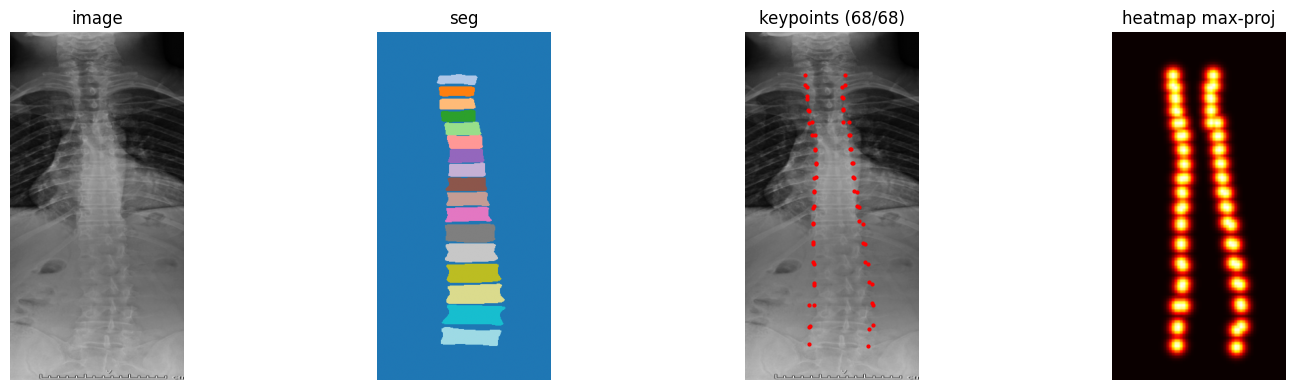

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("image")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("seg")
# overlay first 4 keypoints (corners of T1) on image
axes[2].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(kps_full).all(axis=1)
axes[2].scatter(kps_full[fin, 0], kps_full[fin, 1], s=4, c="red")
axes[2].set_title(f"keypoints ({int(fin.sum())}/68)")
# combined heatmap (max-projection over channels)
axes[3].imshow(hm.max(axis=0), cmap="hot"); axes[3].set_title("heatmap max-proj")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 1.5 · Cobb-Preserving Augmentation (lifted from v3)


In [8]:
def augment_v5_cobb_aware(image, seg):
    """Same chain as augment_v4 but returns a `cobb_preserved` flag that is
    False when elastic_deform fires (which can change the spinal curve).
    Horizontal flip preserves |Cobb|, so it does NOT mask the Cobb target."""
    cobb_preserved = True
    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(
            image, seg,
            angle_range=(-15.0, 15.0),
            translate_frac=0.10,
            scale_range=(0.85, 1.15),
        )
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3:
        image = gamma_correction(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2:
        image = clahe_like(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25:
        image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved


## 2 · Multi-Task Dataset

Wraps `preprocess_case` and adds heatmap rendering + Cobb extraction. Augmentation uses `augment_v5_cobb_aware` on `(image, seg)`, then **re-extracts keypoints from the augmented seg** so they always agree spatially. Cobb GT is invariant under flips and small affine, but **elastic deform** can change the spinal curve — the augmenter returns a `cobb_preserved` flag and we mask Cobb when elastic fires (cheaper than re-deriving post-deform GT).

In [9]:
class MultiTaskSpineDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]

        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)

        # re-extract keypoints from (possibly augmented) seg so they spatially agree
        seg_np = seg.numpy().astype(np.uint8)
        # remapped label space already matches target_ids index → recover raw vertebra IDs
        # by indexing back: 0=bg, 1..17 → target_ids[0..16]
        # multiclass_mask_to_keypoints expects raw IDs, so we rebuild a raw-id mask:
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)
        hm, valid = render_heatmaps(kps_full)

        cobb_val = row.get("cobb_angle_deg")
        has_gt = pd.notna(cobb_val) and cobb_preserved
        cobb_t = torch.tensor(float(cobb_val) if has_gt else 0.0, dtype=torch.float32)
        cobb_valid = torch.tensor(bool(has_gt))

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "cobb": cobb_t,
            "cobb_valid": cobb_valid,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


# sanity check one batch
_ds = MultiTaskSpineDataset(TRAIN_DF.head(4), augment=False)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:14s}  {tuple(v.shape)}  {v.dtype}")


  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool


## 3 · MultiTask Architecture

ResNet-34 encoder (ImageNet-pretrained, grayscale stem) shared across three heads:

- **Seg head**  — 1×1 conv on full-resolution decoder features → 18 logits per pixel (identical to `EncoderUNet`)
- **Kpt head**  — 1×1 conv on H/4 decoder features → 68 heatmaps (matches dataset target resolution, no extra upsample)
- **Cobb head** — global average pool on the bottleneck (B, 512, H/32, W/32) → 2-layer MLP → scalar (degrees)

Encoder/decoder topology mirrors `ai/models/architectures/encoder_unet.py`. Decoder features are tapped at two resolutions (H/4 for keypoints, H for seg).

In [10]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class _Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNet(nn.Module):
    """Shared ResNet-34 encoder with seg + keypoint + Cobb heads."""

    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)

        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)   # produces (B, 64, H/4, W/4) — keypoint tap
        self.up4 = _Up(64, 64, 64)    # produces (B, 64, H/2, W/2)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        # heads
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head,
        ]

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        bridge = self.layer4(s3)  # (B, 512, H/32, W/32) — Cobb tap

        y = self.up1(bridge, s3)
        y = self.up2(y, s2)
        y_q = self.up3(y, s1)              # (B, 64, H/4, W/4) — kpt tap
        y = self.up4(y_q, x0)
        y_full = self.final_up(y)          # (B, 64, H, W)
        y_full = self.drop(y_full)

        seg_logits = self.seg_head(y_full)
        kpt_heatmaps = self.kpt_head(y_q)  # (B, 68, H/4, W/4)
        cobb_norm_pred = self.cobb_head(bridge).squeeze(-1)  # (B,)
        cobb_pred = cobb_norm_pred * self.cobb_norm  # rescale to degrees

        return {
            "seg": seg_logits,
            "kpt": kpt_heatmaps,
            "cobb": cobb_pred,
        }

    def encoder_params(self):
        for m in self._encoder_modules:
            yield from m.parameters()

    def decoder_params(self):
        for m in self._decoder_modules:
            yield from m.parameters()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model = MultiTaskEncoderUNet(pretrained=True, dropout=0.2).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"MultiTaskEncoderUNet total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder+heads: {n_dec:,}")

MultiTaskEncoderUNet total params: 24,501,303
  encoder: 21,278,400  decoder+heads: 3,222,903


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [11]:
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
for k, v in out.items():
    print(f"  {k:6s}  {tuple(v.shape)}  {v.dtype}")

  seg     (1, 18, 512, 256)  torch.float32
  kpt     (1, 68, 128, 64)  torch.float32
  cobb    (1,)  torch.float32


## 5.5 · Differentiable Soft-Argmax + Chain Loss (NEW vs v4)

**Soft-argmax** turns each `(K, H, W)` heatmap into a `(K, 2)` coordinate by computing the softmax-weighted spatial expectation. Differentiable end-to-end. Temperature `T` controls sharpness: small `T` = sharper distribution = closer to true argmax.

**Chain loss** computes 32 pair-distances per sample over the 16 adjacent-vertebra junctions:

| junction | left side | right side |
|---|---|---|
| n → n+1 | `‖soft_argmax(BL_n) − soft_argmax(TL_{n+1})‖` | `‖soft_argmax(BR_n) − soft_argmax(TR_{n+1})‖` |
| n=0..15 | 16 distances | 16 distances |

Distances are normalized by `HM_H` (largest heatmap dim, 128) to land in roughly `[0, 1]` image-relative scale. Per-sample valid mask: a pair `(a, b)` only contributes if BOTH `kpt_valid[a]` and `kpt_valid[b]` are True (handles warn cases with <17 vertebrae).

**Why this should help cobb**: the chain loss enforces vertebra-to-vertebra geometric coherence. Cobb angle is a function of which vertebrae sit at extreme tilt — explicitly chained predictions give the model a structural prior that vertebrae are stacked, which is information v4's per-channel MSE on independent Gaussian targets does NOT communicate. The hypothesis: this prior closes some of the 0.90° gap between v4 Kendall (5.79°) and v4-fixed (6.69°) — that gap is the only remaining lever after schedule-investigation closure and Tier-A rejection.


In [12]:
SOFT_ARGMAX_TEMPERATURE = 20.0  # tuned on GT heatmaps: T=20 -> mean 0.20px / median 0.18px sub-pixel recovery (T=10 -> 12px smear; T=50+ -> 0.85px softmax-saturation quantization)
LAMBDA_CHAIN = 1.0              # weight on chain loss; same scale as λ_kpt


def soft_argmax_2d(heatmap: torch.Tensor, temperature: float = SOFT_ARGMAX_TEMPERATURE) -> torch.Tensor:
    """Differentiable spatial expectation over a heatmap.

    DirectML-compatible: F.softmax handles numerical stability internally — no explicit
    `flat - flat.max(...).values` subtract (which triggers DirectML's partial-dim scatter
    bug in backward when computing grad of max).
    """
    b, k, h, w = heatmap.shape
    weights = F.softmax((heatmap * temperature).view(b, k, h * w), dim=-1).view(b, k, h, w)
    grid_y = torch.arange(h, device=heatmap.device, dtype=heatmap.dtype).view(1, 1, h, 1)
    grid_x = torch.arange(w, device=heatmap.device, dtype=heatmap.dtype).view(1, 1, 1, w)
    cy = (weights * grid_y).sum(dim=(2, 3))  # (B, K)
    cx = (weights * grid_x).sum(dim=(2, 3))  # (B, K)
    return torch.stack([cx, cy], dim=-1)


def chain_loss_fn(
    kpt_heatmap: torch.Tensor,
    kpt_valid: torch.Tensor,
    num_vert: int = NUM_VERT,
    temperature: float = SOFT_ARGMAX_TEMPERATURE,
) -> torch.Tensor:
    """Anatomical chain loss between adjacent vertebra corner predictions.

    For each adjacent pair n -> n+1 (n=0..num_vert-2):
      - Left:  ||soft_argmax(BL_n)  - soft_argmax(TL_{n+1})||
      - Right: ||soft_argmax(BR_n)  - soft_argmax(TR_{n+1})||
    Distances normalized by HM_H (image-relative scale). Pairs are NaN-masked via kpt_valid:
    a pair contributes only if BOTH endpoints are valid.

    DirectML-compatible: vectorized via reshape (B, V, 4, 2) + range-slice indexing.
    Single-int indexing like `coords[:, a]` would trigger select_backward -> scatter
    on DirectML, which fails with 'partially modified dimensions'. Range slices like
    `coords_v[:, :-1, 2:3]` use contiguous narrow ops which are safe.
    """
    coords = soft_argmax_2d(kpt_heatmap, temperature=temperature) / float(HM_H)
    b = coords.shape[0]
    coords_v = coords.view(b, num_vert, 4, 2)   # (B, V, 4, 2) — corner order: TL=0, TR=1, BL=2, BR=3
    valid_v = kpt_valid.view(b, num_vert, 4)    # (B, V, 4)

    # Adjacent vertebrae: upper = vertebrae 0..V-2, lower = vertebrae 1..V-1
    # Corner pairs: BL(upper) <-> TL(lower), BR(upper) <-> TR(lower)
    BL_up = coords_v[:, :-1, 2:3, :].squeeze(2)   # (B, V-1, 2)
    TL_lo = coords_v[:, 1:,  0:1, :].squeeze(2)
    BR_up = coords_v[:, :-1, 3:4, :].squeeze(2)
    TR_lo = coords_v[:, 1:,  1:2, :].squeeze(2)

    BL_v_up = valid_v[:, :-1, 2:3].squeeze(2)     # (B, V-1)
    TL_v_lo = valid_v[:, 1:,  0:1].squeeze(2)
    BR_v_up = valid_v[:, :-1, 3:4].squeeze(2)
    TR_v_lo = valid_v[:, 1:,  1:2].squeeze(2)

    left_mask  = (BL_v_up & TL_v_lo).to(coords.dtype)
    right_mask = (BR_v_up & TR_v_lo).to(coords.dtype)
    left_d  = torch.linalg.norm(BL_up - TL_lo, dim=-1)
    right_d = torch.linalg.norm(BR_up - TR_lo, dim=-1)

    total = (left_d * left_mask).sum() + (right_d * right_mask).sum()
    n_valid = left_mask.sum() + right_mask.sum()
    return total / n_valid.clamp(min=1.0)


# sanity check: soft-argmax recovers GT corner positions on the GT Gaussian heatmaps
_sample = TRAINABLE.iloc[0]
_case = preprocess_case(_sample)
_hm_gt, _valid_gt = render_heatmaps(_case['kps'].numpy())
_hm_t = torch.from_numpy(_hm_gt).unsqueeze(0)         # (1, 68, 128, 64)
_valid_t = torch.from_numpy(_valid_gt).unsqueeze(0)   # (1, 68)
_coords = soft_argmax_2d(_hm_t, temperature=SOFT_ARGMAX_TEMPERATURE).squeeze(0)  # (68, 2) in HM px
_coords_full = _coords.numpy() * HEATMAP_DOWNSAMPLE   # back to full-res px
_gt_full = _case['kps'].numpy()
_finite_mask = np.isfinite(_gt_full).all(axis=1) & _valid_gt
if _finite_mask.any():
    _err_px = np.linalg.norm(_coords_full[_finite_mask] - _gt_full[_finite_mask], axis=1)
    print(f'soft-argmax recovery error on GT heatmaps (T={SOFT_ARGMAX_TEMPERATURE}):')
    print(f'  mean px error: {_err_px.mean():.3f}  max px error: {_err_px.max():.3f}  '
          f'over {int(_finite_mask.sum())}/68 valid corners')
else:
    print('no valid corners in sample — sanity check skipped')

_chain = chain_loss_fn(_hm_t, _valid_t)
print(f'GT-heatmap chain loss (image-relative): {_chain.item():.4f}  '
      f'(=> mean adjacent-corner gap of {_chain.item() * HM_H:.1f} HM-px = {_chain.item() * HM_H * HEATMAP_DOWNSAMPLE:.1f} full-res px)')


soft-argmax recovery error on GT heatmaps (T=20.0):
  mean px error: 0.171  max px error: 0.250  over 68/68 valid corners
GT-heatmap chain loss (image-relative): 0.0071  (=> mean adjacent-corner gap of 0.9 HM-px = 3.7 full-res px)


## 6 · Multi-Task Loss with Chain Term

Four raw losses now, combined via `MixedLossWithChain`:

- **L_seg**, **L_kpt**, **L_cobb** — identical to v4 (CE+Dice / masked MSE / masked smooth-L1)
- **L_chain** — `chain_loss_fn` defined above; image-relative L2 averaged over 32 valid pairs per sample

$$L = \tfrac{1}{2}e^{-s_\text{seg}}\,L_\text{seg} + \tfrac{1}{2}s_\text{seg} + \tfrac{1}{2}e^{-s_\text{cobb}}\,L_\text{cobb} + \tfrac{1}{2}s_\text{cobb} + \lambda_\text{kpt}\,L_\text{kpt} + \lambda_\text{chain}\,L_\text{chain}$$

Same clamped Kendall on `(seg, cobb)`; same fixed `λ_kpt = 1.0`. New `λ_chain = 1.0` is fixed (not learnable) — chain loss is auxiliary supervision, not a Cobb estimator. Holding it fixed avoids the Kendall-amplification pathology v2 hit when the heatmap loss was learnable.


In [13]:
COBB_NORM = 90.0
LAMBDA_KPT = 1.0
LOG_VAR_MIN = -1.5
LOG_VAR_MAX = 4.0


def kpt_loss_fn(pred: torch.Tensor, target: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom


def cobb_loss_fn(
    pred_deg: torch.Tensor,
    target_deg: torch.Tensor,
    valid: torch.Tensor,
    norm: float = COBB_NORM,
) -> torch.Tensor:
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm
    t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)


class ClampedKendallLoss(nn.Module):
    def __init__(
        self,
        task_names: tuple[str, ...] = ("seg", "cobb"),
        log_var_min: float = LOG_VAR_MIN,
        log_var_max: float = LOG_VAR_MAX,
    ):
        super().__init__()
        self.task_names = task_names
        self.log_var = nn.Parameter(torch.zeros(len(task_names)))
        self.log_var_min = log_var_min
        self.log_var_max = log_var_max

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        clamped = self.log_var.clamp(self.log_var_min, self.log_var_max)
        total = 0.0
        parts: dict[str, float] = {}
        for i, name in enumerate(self.task_names):
            lv = clamped[i]
            li = raws[name]
            term = 0.5 * torch.exp(-lv) * li + 0.5 * lv
            total = total + term
            parts[f"raw_{name}"] = float(li.detach().cpu())
            parts[f"log_var_{name}"] = float(self.log_var[i].detach().cpu())
            parts[f"weight_{name}"] = float((0.5 * torch.exp(-lv)).detach().cpu())
        return total, parts


class MixedLossWithChain(nn.Module):
    """v4 mixed Kendall + fixed kpt + NEW fixed chain (Q-18).

    Chain term is added with fixed λ_chain. Held outside Kendall on purpose — chain loss is
    auxiliary supervision (anatomical prior), not a competing task that should be uncertainty-weighted.
    """

    def __init__(self, kpt_weight: float = LAMBDA_KPT, chain_weight: float = LAMBDA_CHAIN) -> None:
        super().__init__()
        self.kendall = ClampedKendallLoss(("seg", "cobb"))
        self.kpt_weight = kpt_weight
        self.chain_weight = chain_weight

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        kendall_total, parts = self.kendall({"seg": raws["seg"], "cobb": raws["cobb"]})
        kpt_term = self.kpt_weight * raws["kpt"]
        chain_term = self.chain_weight * raws["chain"]
        total = kendall_total + kpt_term + chain_term
        parts["raw_kpt"] = float(raws["kpt"].detach().cpu())
        parts["weight_kpt"] = self.kpt_weight
        parts["raw_chain"] = float(raws["chain"].detach().cpu())
        parts["weight_chain"] = self.chain_weight
        parts["loss"] = float(total.detach().cpu())
        return total, parts


def raw_losses_for(out: dict, batch: dict, dev: torch.device) -> dict[str, torch.Tensor]:
    return {
        "seg": seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "kpt": kpt_loss_fn(
            out["kpt"],
            batch["kpt_heatmap"].to(dev),
            batch["kpt_valid"].to(dev),
        ),
        "cobb": cobb_loss_fn(
            out["cobb"],
            batch["cobb"].to(dev),
            batch["cobb_valid"].to(dev),
        ),
        "chain": chain_loss_fn(
            out["kpt"],
            batch["kpt_valid"].to(dev),
            temperature=SOFT_ARGMAX_TEMPERATURE,
        ),
    }


## 7 · Training Loop

Same recipe as v4 (encoder freeze warmup 10 ep, cosine LR, dual-checkpoint dice/cobb, patience 25). Cache root = `ai/models/checkpoints/multitask_v4_chain/` — isolated from v4 and from `multitask_v4_tierA`. `run_config()` includes `chain_loss / lambda_chain / soft_argmax_temperature` fields so the hash differs from both prior runs.


In [14]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v4_chain"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
LR_LOGVAR = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 25
DROPOUT = 0.2


def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNetV4",
        "encoder": "resnet34",
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "heatmap_h": HM_H,
        "heatmap_w": HM_W,
        "heatmap_sigma": HEATMAP_SIGMA,
        "loss": "mixed_clamped_kendall_seg_cobb_plus_fixed_kpt",
        "lambda_kpt": LAMBDA_KPT,
        "chain_loss": "soft_argmax_l2_norm_hm_h",
        "lambda_chain": LAMBDA_CHAIN,
        "soft_argmax_temperature": SOFT_ARGMAX_TEMPERATURE,
        "log_var_min": LOG_VAR_MIN,
        "log_var_max": LOG_VAR_MAX,
        "cobb_norm": COBB_NORM,
        "augment": "v5_cobb_aware",
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "lr_logvar": LR_LOGVAR,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
        "val_frac": 0.2,
    }


def cfg_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]


def find_cached(cfg: dict) -> Path | None:
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None


def new_run_dir(cfg: dict) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = CHECKPOINT_ROOT / f"{stamp}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p


In [15]:
def train_step(
    model: nn.Module,
    loss_module: nn.Module,
    batch: dict,
    optimizer: torch.optim.Optimizer,
) -> dict[str, float]:
    out = model(batch["image"].to(DEVICE))
    raws = raw_losses_for(out, batch, DEVICE)
    total, parts = loss_module(raws)
    optimizer.zero_grad()
    total.backward()
    optimizer.step()
    return parts


@torch.no_grad()
def validate(model: nn.Module, loss_module: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    accum = {
        "loss": 0.0,
        "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_chain": 0.0,
        "weight_seg": 0.0, "weight_cobb": 0.0,
    }
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs_err: list[float] = []
    n_batches = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_chain", "weight_seg", "weight_cobb"):
            accum[k] += parts[k]

        pred_mask = out["seg"].argmax(dim=1)
        seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1] += p.sum() + g.sum()

        valid = batch["cobb_valid"]
        if valid.any():
            cobb_pred = out["cobb"].cpu()[valid]
            cobb_true = batch["cobb"][valid]
            cobb_abs_err.extend((cobb_pred - cobb_true).abs().tolist())
        n_batches += 1

    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n_batches) for k, v in accum.items()},
        "dice": float(dice_per_cls[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs_err)) if cobb_abs_err else float("nan"),
    }


In [16]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = MixedLossWithChain().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    loss_module.load_state_dict(state["loss_module"])
    best_dice = float(metrics_cache["best_val_dice"])
    best_cobb_mae = float(metrics_cache.get("best_val_cobb_mae", float("nan")))
    print(
        f"reused cached run <- {_cached.relative_to(REPO_ROOT)}  "
        f"best_dice={best_dice:.3f}  best_cobb_mae={best_cobb_mae:.2f}°"
    )
else:
    model = MultiTaskEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"MultiTaskEncoderUNet params: {count_params(model):,}  dropout={DROPOUT}")

    train_loader = DataLoader(
        MultiTaskSpineDataset(TRAIN_DF, augment=True),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=multitask_collate,
    )
    val_loader = DataLoader(
        MultiTaskSpineDataset(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate,
    )

    for p in model.encoder_params():
        p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
    ])
    scheduler = None

    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_cobb_mae = float("inf")
    best_dice_state: dict | None = None
    best_cobb_state: dict | None = None
    best_dice_epoch = -1
    best_cobb_epoch = -1
    no_improve = 0  # tracked against dice for early stopping

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
                {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0, "raw_chain": 0.0}
        n_steps = 0
        for batch in train_loader:
            parts = train_step(model, loss_module, batch, optimizer)
            train_acc["loss"] += parts["loss"]
            for k in ("raw_seg", "raw_kpt", "raw_cobb", "raw_chain"):
                train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None:
            scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":         epoch,
            "train_loss":    train_acc["loss"],
            "train_seg":     train_acc["raw_seg"],
            "train_kpt":     train_acc["raw_kpt"],
            "train_cobb":    train_acc["raw_cobb"],
            "train_chain":   train_acc["raw_chain"],
            "val_loss":      val_stats["loss"],
            "val_seg":       val_stats["raw_seg"],
            "val_kpt":       val_stats["raw_kpt"],
            "val_cobb":      val_stats["raw_cobb"],
            "val_chain":     val_stats["raw_chain"],
            "w_seg":         val_stats["weight_seg"],
            "w_cobb":        val_stats["weight_cobb"],
            "val_dice":      val_stats["dice"],
            "val_cobb_mae":  val_stats["cobb_mae_direct"],
            "lr_enc":        float(optimizer.param_groups[0]["lr"]) if n_groups > 2 else 0.0,
            "lr_dec":        float(optimizer.param_groups[-2]["lr"]) if n_groups >= 2 else float(optimizer.param_groups[0]["lr"]),
            "sec":           time.time() - t0,
        }
        history.append(row)

        improved_dice = val_stats["dice"] > best_dice
        improved_cobb = (
            not math.isnan(val_stats["cobb_mae_direct"])
            and val_stats["cobb_mae_direct"] < best_cobb_mae
        )
        if improved_dice:
            best_dice = val_stats["dice"]
            best_dice_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_dice_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
        if improved_cobb:
            best_cobb_mae = val_stats["cobb_mae_direct"]
            best_cobb_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_cobb_epoch = epoch

        flags = ""
        if improved_dice:
            flags += " *D"
        if improved_cobb:
            flags += " *C"
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:6.3f} (s={row['train_seg']:.2f} k={row['train_kpt']:.3f} c={row['train_cobb']:.3f} ch={row['train_chain']:.3f})  "
            f"val={row['val_loss']:6.3f}  dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  ch={row['val_chain']:.3f}  "
            f"w[s/c]={row['w_seg']:.2f}/{row['w_cobb']:.2f}  ({row['sec']:.1f}s){flags}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no dice improvement for {PATIENCE} epochs")
            break

    # restore the best-dice state into the live model (eval cells consume it)
    if best_dice_state is not None:
        model.load_state_dict(best_dice_state["model"])
        loss_module.load_state_dict(best_dice_state["loss_module"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    if best_dice_state is not None:
        torch.save(best_dice_state, run_dir / "model.pt")  # primary ckpt = best dice
    if best_cobb_state is not None:
        torch.save(best_cobb_state, run_dir / "model_best_cobb.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "best_val_dice_epoch": best_dice_epoch,
        "best_val_cobb_mae": best_cobb_mae if best_cobb_mae != float("inf") else None,
        "best_val_cobb_mae_epoch": best_cobb_epoch,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "final_log_var": loss_module.kendall.log_var.detach().cpu().tolist(),
    }, indent=2))
    print(
        f"\ntotal time: {time.time() - t_start:.1f}s  "
        f"best dice={best_dice:.3f}@ep{best_dice_epoch}  "
        f"best cobb_mae={best_cobb_mae:.2f}°@ep{best_cobb_epoch}"
    )
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")


MultiTaskEncoderUNet params: 24,501,303  dropout=0.2
ep   1/150  tr= 0.929 (s=1.45 k=0.094 c=0.056 ch=0.100)  val= 0.982  dice=0.003  cobb= 17.4°  ch=0.021  w[s/c]=0.48/0.53  (13.2s) *D *C
ep   2/150  tr= 0.674 (s=1.33 k=0.019 c=0.045 ch=0.014)  val= 0.655  dice=0.000  cobb= 17.5°  ch=0.026  w[s/c]=0.46/0.55  (12.3s)
ep   3/150  tr= 0.623 (s=1.32 k=0.012 c=0.029 ch=0.012)  val= 0.608  dice=0.000  cobb= 17.7°  ch=0.022  w[s/c]=0.45/0.58  (15.4s)
ep   4/150  tr= 0.587 (s=1.31 k=0.009 c=0.026 ch=0.010)  val= 0.586  dice=0.000  cobb= 22.2°  ch=0.020  w[s/c]=0.43/0.61  (12.6s)
ep   5/150  tr= 0.551 (s=1.29 k=0.009 c=0.024 ch=0.009)  val= 0.535  dice=0.001  cobb= 17.1°  ch=0.013  w[s/c]=0.42/0.64  (15.5s) *C
ep   6/150  tr= 0.528 (s=1.29 k=0.008 c=0.035 ch=0.008)  val= 0.508  dice=0.006  cobb= 19.6°  ch=0.013  w[s/c]=0.42/0.68  (12.2s) *D
ep   7/150  tr= 0.489 (s=1.26 k=0.007 c=0.026 ch=0.008)  val= 0.482  dice=0.012  cobb= 20.3°  ch=0.024  w[s/c]=0.41/0.71  (12.2s) *D
ep   8/150  tr= 0.453 

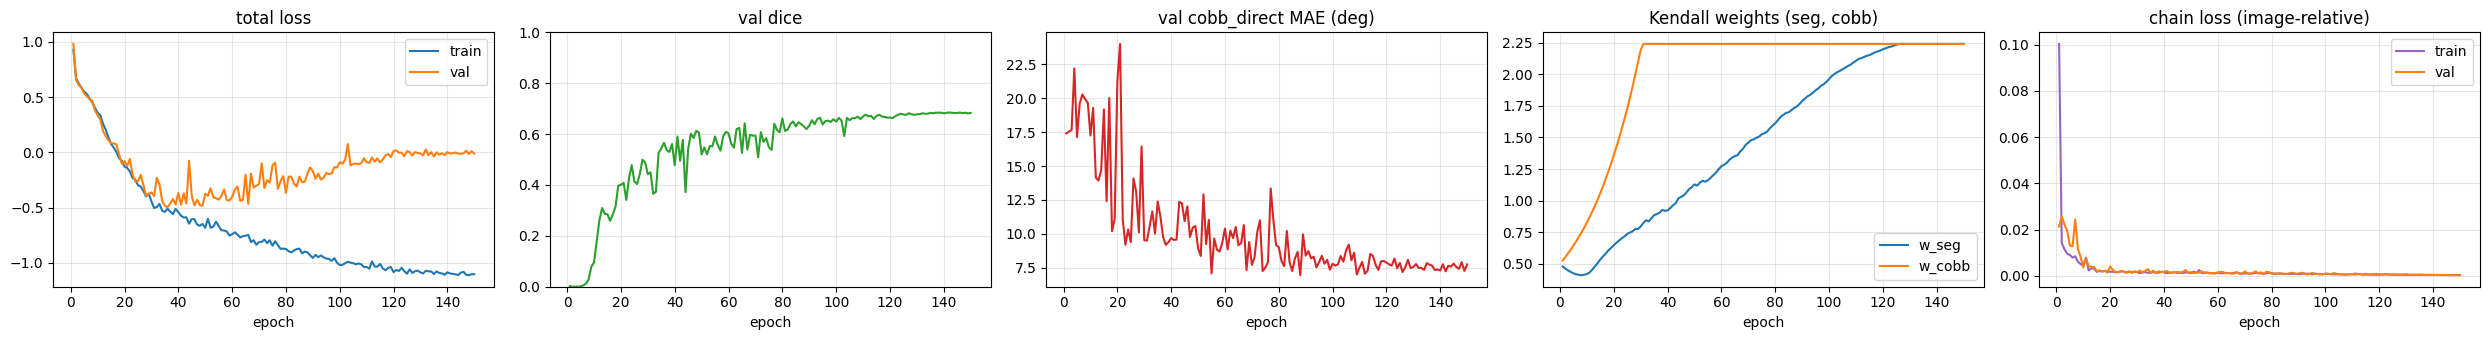

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(25, 3.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="val")
axes[0].set(title="total loss", xlabel="epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_dice"], color="tab:green")
axes[1].set(title="val dice", xlabel="epoch", ylim=(0.0, 1.0))
axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red")
axes[2].set(title="val cobb_direct MAE (deg)", xlabel="epoch")
axes[2].grid(alpha=0.3)

axes[3].plot(history_df["epoch"], history_df["w_seg"],  label="w_seg")
axes[3].plot(history_df["epoch"], history_df["w_cobb"], label="w_cobb")
axes[3].set(title="Kendall weights (seg, cobb)", xlabel="epoch")
axes[3].legend(); axes[3].grid(alpha=0.3)

axes[4].plot(history_df["epoch"], history_df["train_chain"], label="train", color="tab:purple")
axes[4].plot(history_df["epoch"], history_df["val_chain"],   label="val",   color="tab:orange")
axes[4].set(title="chain loss (image-relative)", xlabel="epoch")
axes[4].legend(); axes[4].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7 · Evaluation — Three Cobb Estimators

The multi-task model exposes **three independent paths** to a Cobb angle for the same case:

1. **Direct** — `cobb_head` scalar output
2. **From keypoints** — argmax peaks of the keypoint heatmaps → endplate slopes → Cobb
3. **From segmentation** — `seg_head` argmax → existing `cobb_from_segmentation_tangent`

Compare against ground-truth `cobb_angle_deg` to see which path the multi-task encoder produces best, and whether ensembling all three helps.

In [18]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    """Brute-force pairwise endplate angle.

    coords_xy: (68, 2) float, NaN where keypoint missing. Order: TL, TR, BL, BR per vertebra.
    Returns max absolute difference (deg) between any two endplate slopes.
    """
    angles_top = []
    angles_bot = []
    indices = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v : 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            dy = tr[1] - tl[1]
            dx = tr[0] - tl[0]
            angles_top.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_top.append(np.nan)
        if np.isfinite(bl).all() and np.isfinite(br).all():
            dy = br[1] - bl[1]
            dx = br[0] - bl[0]
            angles_bot.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_bot.append(np.nan)
        indices.append(v)
    a = np.array(angles_top + angles_bot)
    a = a[np.isfinite(a)]
    if len(a) < 2:
        return float("nan")
    diffs = np.abs(a[:, None] - a[None, :])
    return float(diffs.max())


@torch.no_grad()
def evaluate_case(model: nn.Module, row: pd.Series) -> dict:
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_direct = float(out["cobb"].squeeze(0).cpu())

    # dice (mean over present target classes)
    dice_scores: list[float] = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            dice_scores.append(float(2.0 * (p & g).sum() / denom))
    dice_mean = float(np.mean(dice_scores)) if dice_scores else float("nan")

    # Cobb from seg pipeline (existing)
    cobb_from_seg = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    # Cobb from keypoint heatmaps
    coords, _scores = keypoints_from_heatmaps(kpt_hm)
    cobb_from_kpt = cobb_from_keypoints(coords)

    out_row = {
        "dice": dice_mean,
        "cobb_direct": cobb_direct,
        "cobb_from_seg": cobb_from_seg,
        "cobb_from_kpt": cobb_from_kpt,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        for k in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else float("nan")
    return out_row

eval_rows = [evaluate_case(model, r) for _, r in VAL_DF.iterrows()]
eval_df = pd.DataFrame(eval_rows)
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,cobb_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.707126,81.401108,73.564583,327.528808,80.171357,1.229751,6.606774,247.357451
1,0.939194,47.395416,9.916160,315.000000,NaN,NaN,NaN,NaN
2,0.370702,96.693840,122.398189,315.000000,90.000000,6.693840,32.398189,225.000000
3,0.875495,36.775166,10.328704,315.000000,NaN,NaN,NaN,NaN
4,0.879377,36.775166,40.905923,270.000000,37.935438,1.160272,2.970485,232.064562


In [19]:
summary = {
    "n_val":             int(len(eval_df)),
    "mean_dice":         float(eval_df["dice"].mean()),
}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
        err = with_gt[f"{col}_abs_err"].dropna()
        if len(err):
            summary[f"{col}_mae"] = float(err.mean())
            summary[f"{col}_n"] = int(len(err))

print("=== Multi-Task v4 + Q-18 corner-chaining — single 80/20 split ===")
for k, v in summary.items():
    print(f"  {k:30s} {v}")
print()
print("Leaderboard reference (single 80/20):")
print(f"  v4 Kendall (baseline)            dice 0.680   cobb_direct MAE 5.79°  @ ep 54")
print(f"  v4 fixed-weight control          dice 0.683   cobb_direct MAE 6.69°  @ ep 54")
print(f"  v4 + Tier-A (rejected)           dice 0.668   cobb_direct MAE 6.81°  @ ep 59")
print()
print("Q-18 acceptance gate (chain-loss-only ablation):")
print(f"  no-regression: dice >= 0.680")
print(f"  win:           cobb_direct MAE <= 5.79° -> chain prior was the floor-mover; promote to Q-10 stack")
print(f"  modest help:   5.79 < cobb < 6.69       -> proceed to Q-10 / Q-01 anyway")
print(f"  no help:       cobb >= 6.69             -> ablate λ_chain (try 0.1 / 5.0) or temperature (5 / 30) before pivoting to Q-10")

=== Multi-Task v4 + Q-18 corner-chaining — single 80/20 split ===
  n_val                          50
  mean_dice                      0.6847630657773355
  n_with_cobb_gt                 32
  cobb_direct_mae                7.232934933059172
  cobb_direct_n                  32
  cobb_from_seg_mae              12.844300782451501
  cobb_from_seg_n                32
  cobb_from_kpt_mae              238.01135070843912
  cobb_from_kpt_n                32

Leaderboard reference (single 80/20):
  v4 Kendall (baseline)            dice 0.680   cobb_direct MAE 5.79°  @ ep 54
  v4 fixed-weight control          dice 0.683   cobb_direct MAE 6.69°  @ ep 54
  v4 + Tier-A (rejected)           dice 0.668   cobb_direct MAE 6.81°  @ ep 59

Q-18 acceptance gate (chain-loss-only ablation):
  no-regression: dice >= 0.680
  win:           cobb_direct MAE <= 5.79° -> chain prior was the floor-mover; promote to Q-10 stack
  modest help:   5.79 < cobb < 6.69       -> proceed to Q-10 / Q-01 anyway
  no help:     

## 8 · Qualitative Check

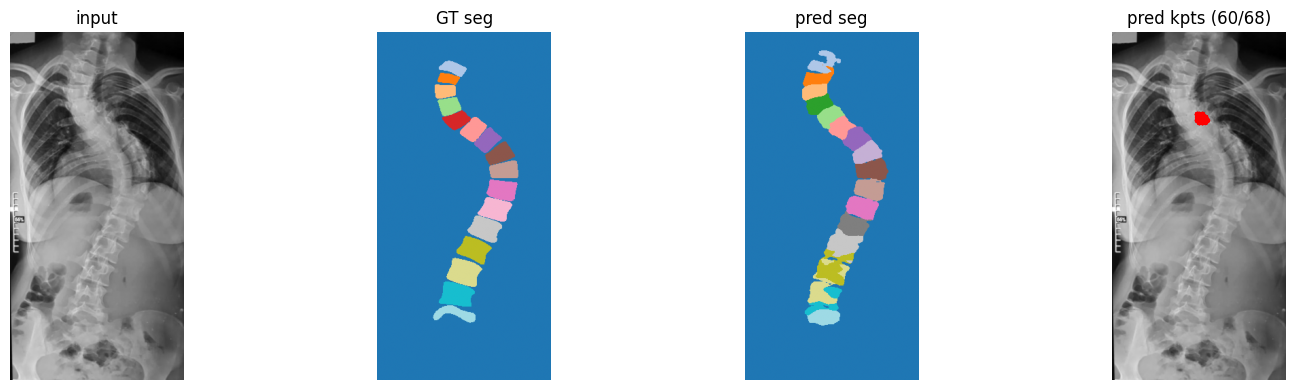

In [20]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
kpt_hm = out["kpt"].squeeze(0).cpu()
coords, scores = keypoints_from_heatmaps(kpt_hm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(seg_pred, cmap="tab20"); axes[2].set_title("pred seg")
axes[3].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(coords).all(axis=1)
axes[3].scatter(coords[fin, 0], coords[fin, 1], s=8, c="red")
axes[3].set_title(f"pred kpts ({int(fin.sum())}/68)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 9 · Conclusions

TODO after the run: fill in mean dice / cobb_direct MAE / r / sev_acc and the per-cell deltas vs the v4 baseline row in [[hot.md]] §Leaderboard.

Decision tree per [[hot.md]] §Active Threads:
- **Δcobb ≥ 1.0°** → chain prior was dominant gap → promote to Q-10 AASCE19 (gated on access) or Q-01 5-fold CV.
- **0.0° < Δcobb < 1.0°** → modest help → still promote to Q-10 / Q-01.
- **Δcobb ≤ 0.0°** → ablate `λ_chain` (try 0.1 / 5.0) and `SOFT_ARGMAX_TEMPERATURE` (try 5 / 30). If still no help across the lambda/T grid, file as negative result and pivot to Q-10 directly (skipping the per-component Tier-A ablation since both preprocessing AND chain-prior would have failed).

Note: track `train_chain` and `val_chain` curves — if chain loss converges to a value much smaller than the GT-heatmap reference (~0.05–0.10 image-relative), the chain prior is being satisfied but isn't moving cobb. That's diagnostic of "chain coherence achieved but cobb still relies on direct features" → feed into the Q-12 PCGrad probe queue.
